In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
data = pd.read_csv("UNSW_NB15_training-set.csv")
data.head(30)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0
5,6,0.380537,tcp,-,FIN,10,6,534,268,39.417980,...,1,40,0,0,0,2,39,0,Normal,0
6,7,0.637109,tcp,-,FIN,10,8,534,354,26.683033,...,1,40,0,0,0,1,39,0,Normal,0
7,8,0.521584,tcp,-,FIN,10,8,534,354,32.593026,...,1,40,0,0,0,3,39,0,Normal,0
8,9,0.542905,tcp,-,FIN,10,8,534,354,31.313031,...,1,40,0,0,0,3,39,0,Normal,0
9,10,0.258687,tcp,-,FIN,10,6,534,268,57.985135,...,1,40,0,0,0,3,39,0,Normal,0


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [4]:
data['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = le.fit_transform(data[column])


In [7]:
X = data.drop('label', axis=1)
y = data['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
import pandas as pd
data = pd.read_csv("UNSW_NB15_training-set.csv")


In [10]:
data.isnull().sum()


id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [11]:
data.duplicated().sum()


np.int64(0)

In [12]:
data[data.duplicated()]


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label


In [13]:
data = data.drop_duplicates()


In [14]:
data['attack_cat']


0            Normal
1            Normal
2            Normal
3            Normal
4            Normal
            ...    
175336      Generic
175337    Shellcode
175338      Generic
175339      Generic
175340      Generic
Name: attack_cat, Length: 175341, dtype: object

In [15]:
data['attack_cat'].nunique()


10

In [16]:
data['attack_cat'].value_counts()


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [17]:
data.isnull().sum()


id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [18]:
data.isnull().sum().sum()


np.int64(0)

In [19]:

print(data.shape)


(175341, 45)


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['proto', 'service', 'state', 'attack_cat']
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [21]:
X = data.drop(['label', 'id', 'attack_cat'], axis=1)
y = data['label']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Then scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93     16772
           1       0.96      0.98      0.97     35831

    accuracy                           0.96     52603
   macro avg       0.96      0.95      0.95     52603
weighted avg       0.96      0.96      0.96     52603



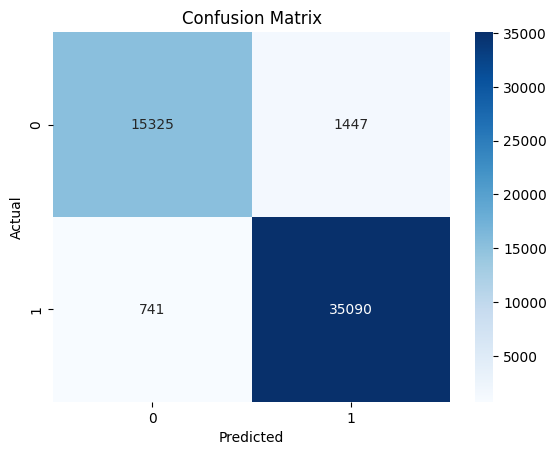

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

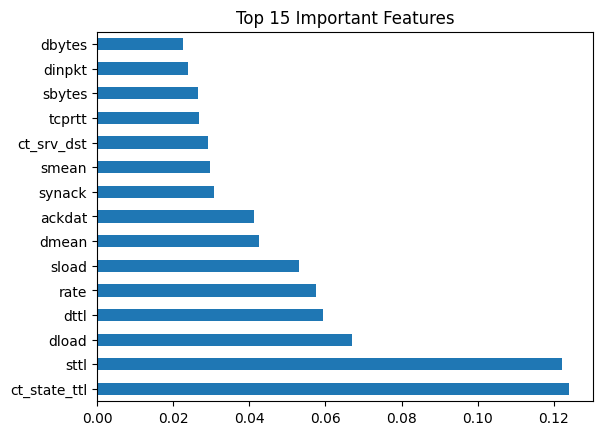

In [24]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Important Features')
plt.show()

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf.predict(X_test_scaled)  # use rf and scaled test data

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.958405414139878

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93     16772
           1       0.96      0.98      0.97     35831

    accuracy                           0.96     52603
   macro avg       0.96      0.95      0.95     52603
weighted avg       0.96      0.96      0.96     52603



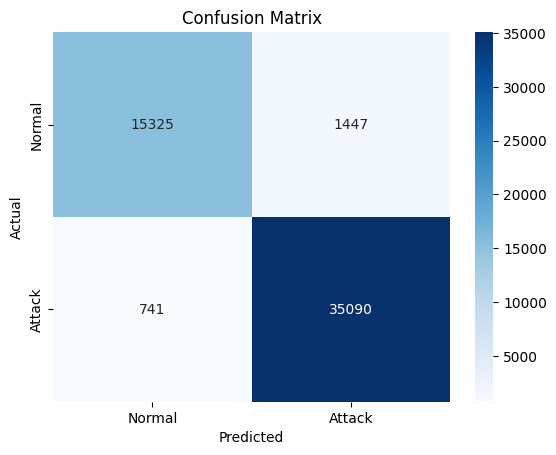

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

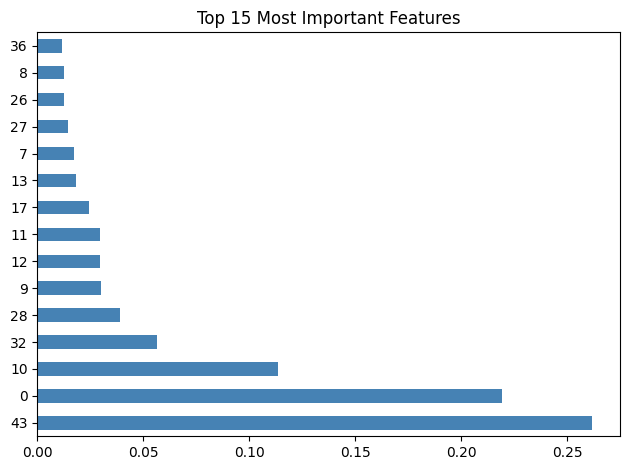

In [27]:
feat_importances = pd.Series(model.feature_importances_)
feat_importances.nlargest(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"{name}: {accuracy_score(y_test, pred):.4f}")

Decision Tree: 0.9468
Logistic Regression: 0.8438


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


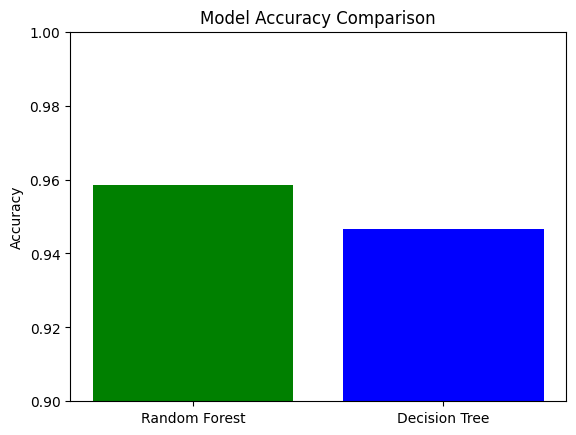

In [29]:
results = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'Decision Tree': accuracy_score(y_test, 
                     DecisionTreeClassifier().fit(X_train, y_train).predict(X_test)),
}

plt.bar(results.keys(), results.values(), color=['green', 'blue'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.show()

In [30]:
import joblib

joblib.dump(model, 'best_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# select best features
selector = SelectKBest(f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)

selected_cols = X.columns[selector.get_support()]
print("Selected Features:", selected_cols.tolist())

Selected Features: ['state', 'rate', 'sttl', 'sload', 'dload', 'sinpkt', 'swin', 'stcpb', 'dtcpb', 'dwin', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [32]:
!pip3 install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# define features and target
X = data.drop('label', axis=1)
y = data['label']

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# select best features
selector = SelectKBest(f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)

selected_cols = X.columns[selector.get_support()]
print("Selected Features:", selected_cols.tolist())

Selected Features: ['id', 'state', 'rate', 'sttl', 'dload', 'swin', 'stcpb', 'dtcpb', 'dwin', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat']


In [34]:
X = data.drop(['label', 'id', 'attack_cat'], axis=1)
y = data['label']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy:", accuracy_score(y_test, pred))

Decision Tree Accuracy: 0.9463338592855921
Logistic Regression Accuracy: 0.9319620553960801
SVM Accuracy: 0.9361063057240081


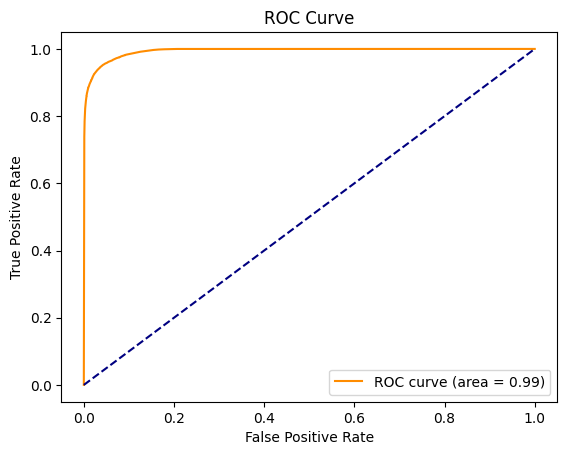

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = rf.predict_proba(X_test_scaled)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

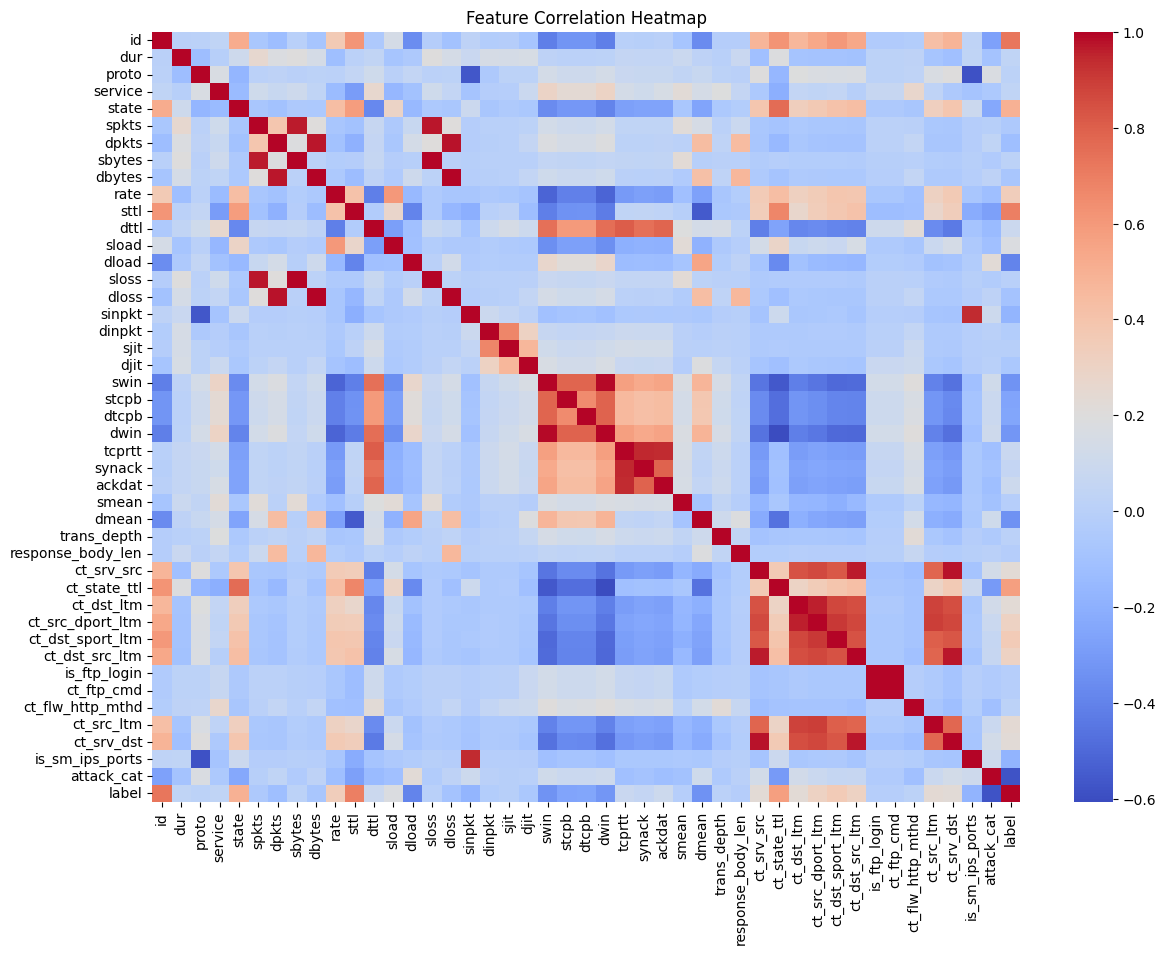

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

In [58]:
data = pd.read_csv("UNSW_NB15_training-set.csv")

print(data.shape)
data.head()

(175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [59]:
le = LabelEncoder()

cat_cols = ['proto', 'service', 'state', 'attack_cat']

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [53]:
X = data.drop(['label','id','attack_cat'], axis=1)
y = data['label']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Random Forest": rf,
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for name, model in models.items():
    if name != "Random Forest":
        model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy: {accuracy_score(y_test, pred):.4f}")

Random Forest Accuracy: 0.9584
Decision Tree Accuracy: 0.9467
Logistic Regression Accuracy: 0.9320
SVM Accuracy: 0.9361


In [60]:
import joblib

In [61]:
joblib.dump(rf, "nids_random_forest_model.pkl")

['nids_random_forest_model.pkl']

In [62]:
joblib.dump(rf, "nids_random_forest_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [63]:
loaded_model = joblib.load("nids_random_forest_model.pkl")

In [64]:
predictions = loaded_model.predict(X_test_scaled)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load dataset
data = pd.read_csv("UNSW_NB15_training-set.csv")

# Encode categorical columns
cat_cols = ['proto','service','state','attack_cat']
encoder = LabelEncoder()

for col in cat_cols:
    data[col] = encoder.fit_transform(data[col])

# Define features and target
X = data.drop(['label'], axis=1)
y = data['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "rf_intrusion_model.pkl")

print("Model trained and saved successfully")

Model trained and saved successfully


In [3]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load trained model
model = joblib.load("rf_intrusion_model.pkl")

# Load traffic data to test
test_data = pd.read_csv("UNSW_NB15_training-set.csv")

# Encode categorical columns
cat_cols = ['proto','service','state','attack_cat']
encoder = LabelEncoder()

for col in cat_cols:
    test_data[col] = encoder.fit_transform(test_data[col])

# Remove label column for prediction
X_test = test_data.drop(['label'], axis=1)

# Predict
predictions = model.predict(X_test)

# Convert predictions to readable output
results = []
for p in predictions:
    if p == 0:
        results.append("SAFE")
    else:
        results.append("MALICIOUS")

# Add prediction column
test_data['Traffic_Status'] = results

print(test_data[['Traffic_Status']].head())

  Traffic_Status
0           SAFE
1           SAFE
2           SAFE
3           SAFE
4           SAFE


In [21]:
import joblib

model = joblib.load("rf_intrusion_model.pkl")

sample = X_test.iloc[[4]]   # keep dataframe format

prediction = model.predict(sample)

if prediction[0] == 0:
    print("Traffic is SAFE")
else:
    print("Traffic is MALICIOUS")

Traffic is SAFE


In [20]:
sample = X_test.iloc[[47911]]
print(sample)

prediction = model.predict(sample)

print("Prediction:", prediction)

          id       dur  proto  service  state  spkts  dpkts  sbytes  dbytes  \
47911  47912  0.000009     20        0      3      2      0     200       0   

              rate  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
47911  111111.1072  ...                 1                 1               4   

       is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \
47911             0           0                 0           2           4   

       is_sm_ips_ports  attack_cat  
47911                0           1  

[1 rows x 44 columns]
Prediction: [1]


In [19]:
predictions = model.predict(X_test)

# Add predictions to dataframe
results = X_test.copy()
results['Prediction'] = predictions

# Find malicious traffic
malicious_rows = results[results['Prediction'] == 1]

print(malicious_rows)

            id       dur  proto  service  state  spkts  dpkts  sbytes  dbytes  \
47911    47912  0.000009     20        0      3      2      0     200       0   
47912    47913  0.000009     53        0      3      2      0     200       0   
47913    47914  0.000009     12        0      3      2      0     200       0   
47914    47915  0.000003    128        0      3      2      0     200       0   
47915    47916  0.000008     87        0      3      2      0     200       0   
...        ...       ...    ...      ...    ...    ...    ...     ...     ...   
175336  175337  0.000009    119        2      3      2      0     114       0   
175337  175338  0.505762    113        0      2     10      8     620     354   
175338  175339  0.000009    119        2      3      2      0     114       0   
175339  175340  0.000009    119        2      3      2      0     114       0   
175340  175341  0.000009    119        2      3      2      0     114       0   

                 rate  ... 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [23]:
data = pd.read_csv("UNSW_NB15_training-set.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [24]:
total_records = len(data)
normal_count = sum(data['label'] == 0)
attack_count = sum(data['label'] == 1)

print("Total Traffic:", total_records)
print("Normal Traffic:", normal_count)
print("Malicious Traffic:", attack_count)

Total Traffic: 175341
Normal Traffic: 56000
Malicious Traffic: 119341


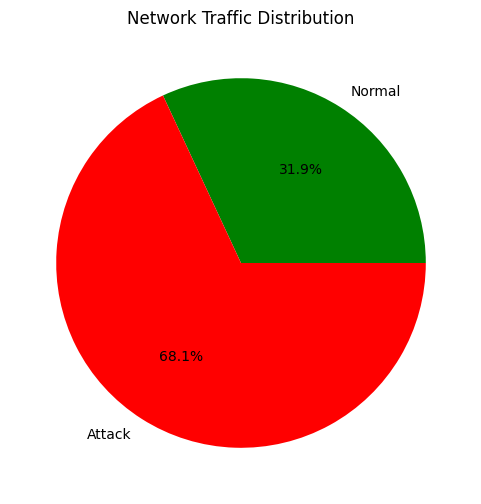

In [25]:
labels = ['Normal', 'Attack']
sizes = [normal_count, attack_count]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green','red'])
plt.title("Network Traffic Distribution")
plt.show()

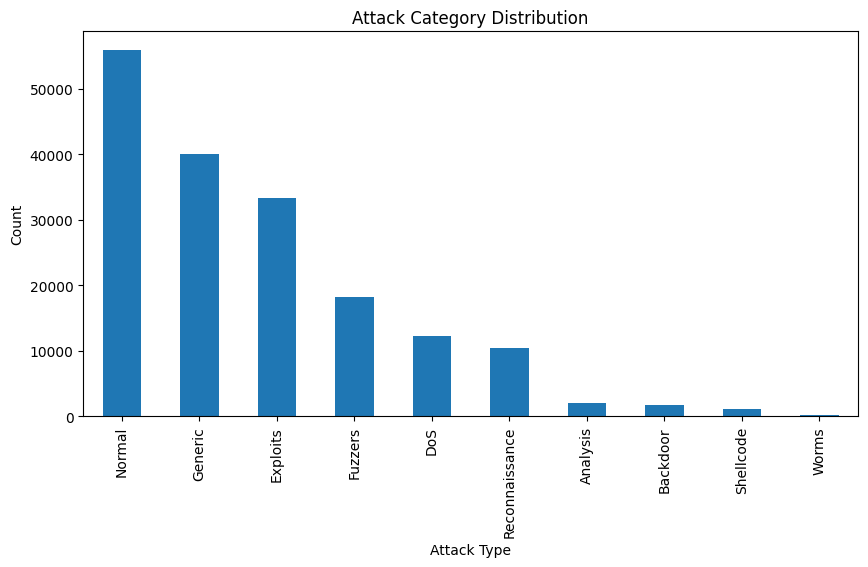

In [26]:
plt.figure(figsize=(10,5))
data['attack_cat'].value_counts().plot(kind='bar')
plt.title("Attack Category Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()

In [27]:
cat_cols = ['proto','service','state','attack_cat']
encoder = LabelEncoder()

for col in cat_cols:
    data[col] = encoder.fit_transform(data[col])

In [28]:
X = data.drop('label', axis=1)
y = data['label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 1.0


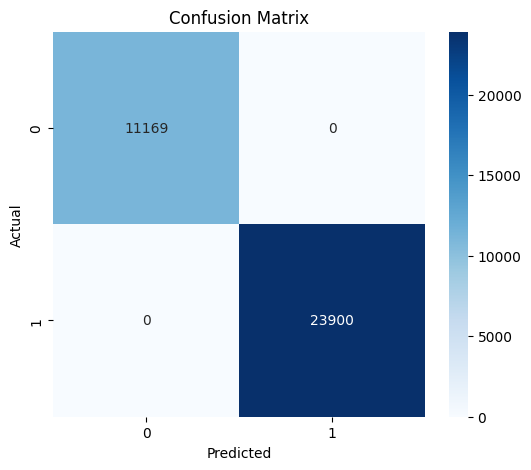

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

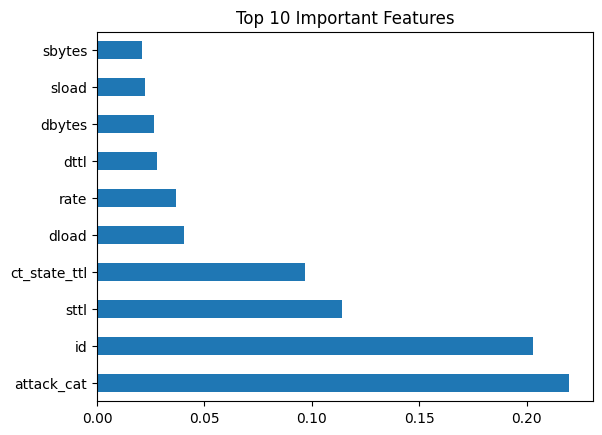

In [32]:
importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)

feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


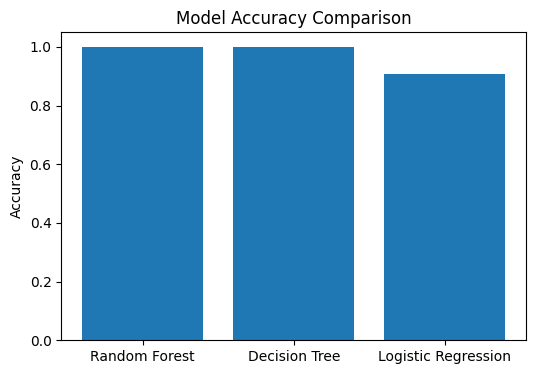

In [35]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, pred)

plt.figure(figsize=(6,4))
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

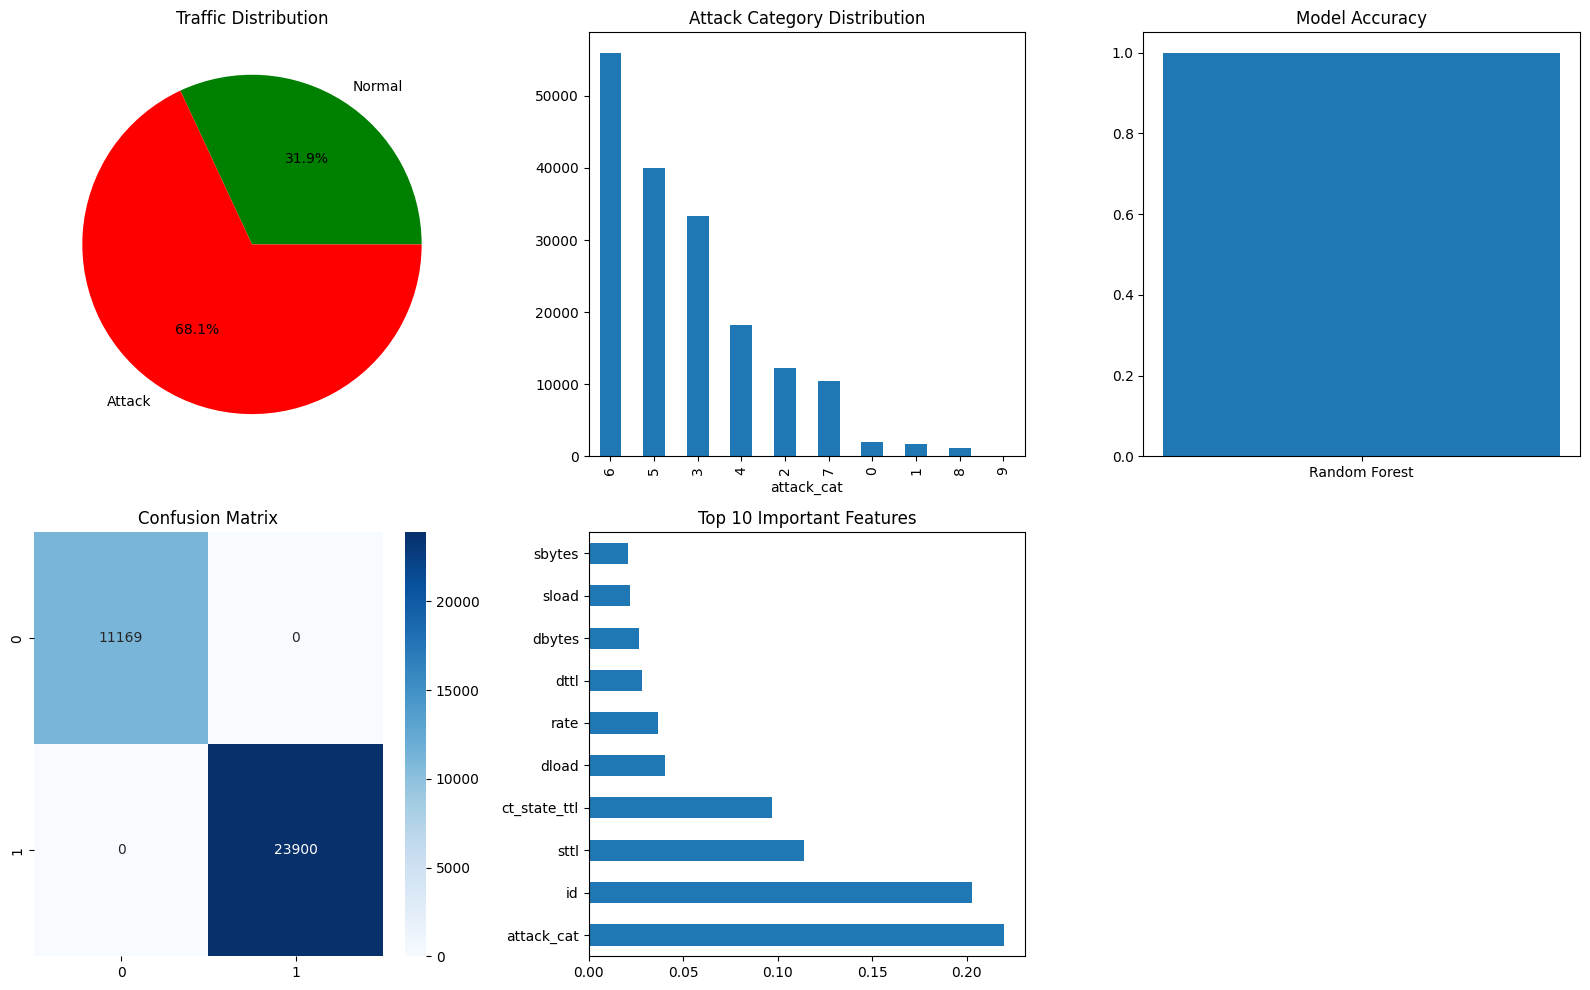

===== NIDS DASHBOARD SUMMARY =====
Total Traffic: 175341
Normal Traffic: 56000
Malicious Traffic: 119341
Model Accuracy: 100.0 %


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
data = pd.read_csv("UNSW_NB15_training-set.csv")

# Encode categorical features
cat_cols = ['proto','service','state','attack_cat']
encoder = LabelEncoder()

for col in cat_cols:
    data[col] = encoder.fit_transform(data[col])

# Dataset statistics
total = len(data)
normal = sum(data['label'] == 0)
attack = sum(data['label'] == 1)

# Prepare ML data
X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)

# Create dashboard layout
plt.figure(figsize=(16,10))

# Traffic distribution
plt.subplot(2,3,1)
plt.pie([normal,attack],
        labels=["Normal","Attack"],
        autopct='%1.1f%%',
        colors=['green','red'])
plt.title("Traffic Distribution")

# Attack categories
plt.subplot(2,3,2)
data['attack_cat'].value_counts().plot(kind='bar')
plt.title("Attack Category Distribution")

# Model accuracy
plt.subplot(2,3,3)
plt.bar(["Random Forest"],[accuracy])
plt.title("Model Accuracy")

# Confusion matrix
plt.subplot(2,3,4)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")

# Feature importance
plt.subplot(2,3,5)
importance = model.feature_importances_
feat = pd.Series(importance, index=X.columns)
feat.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")

plt.tight_layout()
plt.show()

# Print summary metrics
print("===== NIDS DASHBOARD SUMMARY =====")
print("Total Traffic:", total)
print("Normal Traffic:", normal)
print("Malicious Traffic:", attack)
print("Model Accuracy:", round(accuracy*100,2), "%")